# 09 — Cross-asset / sentiment agent (self-contained)

The structurally-**orthogonal** learned agent: it trades a *different information source* than the
price-feature models — cross-asset relationships (ETH/BTC, BTC dominance), market sentiment
(Fear & Greed) and order-flow microstructure.

**Leak discipline.** Features exclude the known forward leak (`mkt_total_mcap_chg_24h`), the
momentum-redundant `cross_altcoin_breadth_24h` (0.56 corr with the realised 24h move), the sparse
`mkt_stablecoin_pct`, and raw price levels. Label = triple-barrier (2σ/24h). Model = LightGBM,
expanding-window walk-forward, retrained quarterly with a 48h embargo covering the label horizon.
Bracket params grid-searched on 2022-01→2024-05 only, frozen for OOS.

> **Honest expectation:** orthogonal info is a *diversification* hypothesis, not a guaranteed edge —
> the OOS AUC and the random-bracket null (notebook 07) tell you whether it carries real skill.

Self-contained: engine + agent inlined below. Artifacts → `artifacts/notebooks_v2/09_crossasset/`.

## 1 · Engine — inlined

In [1]:
import json
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

# Learned agents (nonlinear models on the shared feature panel) + rule agents (notebook 08,
# parameter-free classical strategies). The rule agents are structurally orthogonal — their edge
# is strategy logic, not the feature panel — which is what gives the coordinator something to
# rotate into when the learned agents fail together.
LEARNED_AGENTS = ["lgbm", "mamba", "tcn", "patch"]
RULE_AGENTS = ["trend", "meanrev", "volbreak"]
CROSS_AGENTS = ["crossasset"]   # learned, but on orthogonal cross-asset/sentiment/flow info
AGENTS = LEARNED_AGENTS + RULE_AGENTS + CROSS_AGENTS
AGENT_DIR = {"lgbm": "01_lgbm", "mamba": "02_mamba", "tcn": "03_tcn", "patch": "05_patchtst",
             "trend": "08_trend", "meanrev": "08_meanrev", "volbreak": "08_volbreak",
             "crossasset": "09_crossasset"}
# Multiclass TBM agents emit two *independent* softmax channels (P-up, P-down) and decide
# long on P-up and short on P-down. A single saved probability is the P-up channel only, so
# these agents must be backtested with their P-down channel too — otherwise the binary engine
# manufactures shorts whenever P-up is merely low, destroying their genuine (short-heavy) edge.
MULTICLASS = {"tcn", "patch"}
PARADIGM = {
    "lgbm": "gradient boosting (tabular)",
    "mamba": "selective state-space",
    "tcn": "dilated causal conv.",
    "patch": "patch transformer",
    "trend": "rule: trend-following",
    "meanrev": "rule: mean-reversion",
    "volbreak": "rule: volatility breakout",
    "crossasset": "learned: cross-asset / sentiment / flow",
}

OOS_START = pd.Timestamp("2024-05-31")
OOS_END = pd.Timestamp("2026-05-16")
COMPETENCE_START = pd.Timestamp("2023-01-01")  # pre-OOS window common to all four agents

REGIMES = ("chop", "bull", "bear")
REGIME_DATES = {  # reporting-only OOS sub-periods; the live detector is feature-based
    "chop": (pd.Timestamp("2024-05-31"), pd.Timestamp("2024-11-05")),
    "bull": (pd.Timestamp("2024-11-06"), pd.Timestamp("2025-10-31")),
    "bear": (pd.Timestamp("2025-11-01"), pd.Timestamp("2026-05-31")),
}

# Fee model — identical to the base agents' backtests.
MAKER_FEE = 0.0
TAKER_FEE = 0.0005
BUFFER = 0.0005
SHORT_FUNDING_H = 0.0000077
REALLOC_FEE = 0.0002       # capital reallocation cost across agents (per unit |Δweight|)

EMBARGO_H = 48   # embargo applied to every trailing/online statistic
ANN = np.sqrt(24 * 365)

# --- Coordinator defaults (a-priori reasonable; NOT tuned on the OOS window) -------------
# A 60-day trailing window to score each agent's recent skill, a neutral softmax temperature,
# and a 7-day regime-smoothing window to suppress the whipsaw that wrecks instantaneous routing.
# Proper selection of these belongs on pre-OOS data (purged CV) and is left as future work.
PERF_WIN = 1440        # 60-day trailing window for the online performance score
PERF_TEMP = 0.75       # softmax temperature over trailing Sharpe
REGIME_SMOOTH = 168    # 7-day majority-vote smoothing of the regime label
COMP_FLOOR = 0.15      # floor on the competence tilt so a hot agent is never fully vetoed


def repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("repo root not found")


# ---------------------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------------------

def sharpe(eq: np.ndarray) -> float:
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * ANN)


def sortino(eq: np.ndarray) -> float:
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    neg = r[r < 0]
    d = neg.std(ddof=1) if len(neg) > 1 else 1e-12
    return float(r.mean() / (d + 1e-12) * ANN)


def maxdd(eq: np.ndarray) -> float:
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())


# ---------------------------------------------------------------------------
# ATR-bracket engine — the agents' own risk-managed execution
# ---------------------------------------------------------------------------

def bracket_run(prob, close, high, low, atr, *, long_threshold, short_threshold,
                entry_atr_mult, sl_atr_mult, tp_atr_mult, min_hold, max_hold, cooldown,
                min_sl=0.01, with_fees=True, prob_dn=None, **_ignored):
    """Single-pass ATR-bracket backtester (identical logic to the base agents).

    Returns three full-length arrays: the equity curve ``eq``, the held position ``pos`` in
    ``{-1, 0, +1}``, and a held ``conf`` in ``[0, 1]`` (entry-probability strength carried for
    the life of the trade). Equity is net of the maker/taker fee model and short funding.

    ``prob_dn`` selects the entry convention:

    * ``None`` — binary single-probability agent (LightGBM, Mamba): long when
      ``prob > long_threshold``, short when ``prob < short_threshold``.
    * an array — multiclass TBM agent (TCN, PatchTST): ``prob`` is the P-up channel and
      ``prob_dn`` the P-down channel; long when ``prob > long_threshold``, short when
      ``prob_dn > short_threshold`` (long takes priority, mirroring the base notebooks).
    """
    n = len(close)
    eq = np.ones(n); pos = np.zeros(n); conf = np.zeros(n)
    cur = 1.0
    in_pos = False; direction = None
    entry_px = sl_px = tp_px = pos_eq = entry_fee = 0.0
    held_conf = 0.0; hold = cd = 0; funding = 0.0; pend = None
    for i in range(n):
        lo, hi, px = low[i], high[i], close[i]
        if in_pos:
            hold += 1
            if direction == "short":
                funding += SHORT_FUNDING_H
            eq[i] = pos_eq * (px / entry_px if direction == "long" else 1 + (entry_px - px) / entry_px)
            pos[i] = 1.0 if direction == "long" else -1.0
            conf[i] = held_conf
            ex = False; xpx = 0.0; xf = 0.0
            if hold >= min_hold:
                if direction == "long":
                    if lo <= sl_px: xpx, ex, xf = sl_px, True, (TAKER_FEE if with_fees else 0.0)
                    elif hi >= tp_px: xpx, ex, xf = tp_px, True, MAKER_FEE
                    elif hold >= max_hold: xpx, ex, xf = px, True, (TAKER_FEE if with_fees else 0.0)
                else:
                    if hi >= sl_px: xpx, ex, xf = sl_px, True, (TAKER_FEE if with_fees else 0.0)
                    elif lo <= tp_px: xpx, ex, xf = tp_px, True, MAKER_FEE
                    elif hold >= max_hold: xpx, ex, xf = px, True, (TAKER_FEE if with_fees else 0.0)
            if ex:
                g = ((xpx - entry_px) / entry_px if direction == "long" else (entry_px - xpx) / entry_px)
                net = g - (entry_fee + xf if with_fees else 0.0) + funding
                cur = pos_eq * (1.0 + net); eq[i] = cur
                in_pos = False; cd = cooldown; funding = 0.0
        elif pend is not None:
            d, lim, ps, pt, pc = pend
            if d == "long":
                fill = lo <= lim + BUFFER
                ef = MAKER_FEE if (fill and with_fees) else (TAKER_FEE if with_fees else 0.0)
            else:
                fill = hi >= lim - BUFFER
                ef = MAKER_FEE if (fill and with_fees) else (TAKER_FEE if with_fees else 0.0)
            entry_px = lim if fill else px
            sl_px, tp_px, entry_fee = ps, pt, ef
            direction = d; in_pos = True; pos_eq = cur; hold = 0; funding = 0.0
            held_conf = pc; pos[i] = 1.0 if d == "long" else -1.0; conf[i] = pc
            eq[i] = cur; pend = None
        elif cd > 0:
            cd -= 1; eq[i] = cur
        elif not np.isnan(prob[i]) and i + 1 < n:
            a = max(atr[i], min_sl)
            if prob_dn is None:
                go_long, go_short = prob[i] > long_threshold, prob[i] < short_threshold
                pc_long = pc_short = float(np.clip(2 * abs(prob[i] - 0.5), 0, 1))
            else:
                go_long, go_short = prob[i] > long_threshold, prob_dn[i] > short_threshold
                pc_long = float(np.clip(2 * abs(prob[i] - 0.5), 0, 1))
                pc_short = float(np.clip(2 * abs(prob_dn[i] - 0.5), 0, 1))
            if go_long:
                pend = ("long", px * (1 - entry_atr_mult * a), px * (1 - sl_atr_mult * a),
                        px * (1 + tp_atr_mult * a), pc_long)
            elif go_short:
                pend = ("short", px * (1 + entry_atr_mult * a), px * (1 + sl_atr_mult * a),
                        px * (1 - tp_atr_mult * a), pc_short)
            eq[i] = cur
        else:
            eq[i] = cur
    return eq, pos, conf


# ---------------------------------------------------------------------------
# Regime detector (feature-based, works across all history -> leak-free priors)
# ---------------------------------------------------------------------------

class RegimeDetector:
    """Label each bar ``chop`` / ``bull`` / ``bear`` from *stationary* trend/volatility features
    only. Calendar/monotonic features are deliberately excluded (they caused the meta-learner's
    regime memorisation). The same detector is applied pre-OOS and OOS, which is what lets
    per-regime competence be estimated without leakage.
    """

    def __init__(self, chop_hurst: float = 0.5):
        self.chop_hurst = chop_hurst

    def label(self, df: pd.DataFrame) -> pd.Series:
        trend = df["close_vs_sma_200"] if "close_vs_sma_200" in df else df["sma100_vs_sma200"]
        sideways = df.get("sideways_flag", pd.Series(0, index=df.index)).fillna(0).astype(bool)
        hurst = df.get("hurst_24h", pd.Series(0.5, index=df.index)).fillna(0.5)
        is_chop = sideways | (hurst < self.chop_hurst)
        out = np.where(trend.fillna(0) >= 0, "bull", "bear")
        out = np.where(is_chop, "chop", out)
        return pd.Series(out, index=df.index, name="regime")


# ---------------------------------------------------------------------------
# Data panel
# ---------------------------------------------------------------------------

def _load_signal(a2: Path, sub: str, kind: str, value: str = "probs") -> pd.Series:
    """Load one channel of an agent's signal. ``value`` picks the file suffix
    (``probs`` -> ``{kind}_probs.npy``, ``pdown`` -> ``{kind}_pdown.npy``); both share
    the ``{kind}_index.npy`` timestamps."""
    f = a2 / sub
    p = np.load(f / f"{kind}_{value}.npy")
    idx = pd.to_datetime(np.load(f / f"{kind}_index.npy"), unit="ns")
    return pd.Series(p, index=idx)


def _spliced_signal(a2: Path, sub: str, index: pd.Index, value: str = "probs") -> pd.Series:
    """Walk-forward signal over full history, with the OOS window overwritten by the
    held-out OOS signal (the same splice used for the P-up channel)."""
    wfo = _load_signal(a2, sub, "wfo", value).reindex(index)
    oos = _load_signal(a2, sub, "oos", value).reindex(index)
    mask = (index >= OOS_START) & (index <= OOS_END) & oos.notna()
    wfo.loc[mask] = oos.loc[mask]
    return wfo


def load_panel() -> pd.DataFrame:
    """Aligned panel: each agent's walk-forward probability over full history spliced with its
    OOS probability over the OOS window, plus price, return, regime and stationary features.
    """
    repo = repo_root()
    a2 = repo / "artifacts" / "notebooks_v2"
    df = pd.read_parquet(repo / "data" / "features" / "BTCUSDT_1h_unified.parquet")
    df.index = df.index.tz_localize(None) if df.index.tz else df.index

    panel = pd.DataFrame(index=df.index)
    for a in AGENTS:
        panel[a] = _spliced_signal(a2, AGENT_DIR[a], df.index)
        if a in MULTICLASS:  # P-down channel for the dual-channel TBM agents
            panel[f"{a}_dn"] = _spliced_signal(a2, AGENT_DIR[a], df.index, "pdown")

    for c in ["close", "high", "low", "atr_14_pct", "close_vs_sma_200", "sma100_vs_sma200",
              "sideways_flag", "hurst_24h", "bb_width_pct", "vol_ratio_24h", "trend_score"]:
        if c in df:
            panel[c] = df[c]
    panel["ret"] = df["close"].pct_change().fillna(0.0)
    panel["regime"] = RegimeDetector().label(df)
    return panel


# ---------------------------------------------------------------------------
# Agents — autonomous, risk-managed traders
# ---------------------------------------------------------------------------

@dataclass
class TradingAgent:
    """One base model wrapped as an autonomous, risk-managed trading agent.

    On :meth:`build` it runs its own tuned ATR-bracket strategy over the full history, yielding a
    realised equity curve, a per-bar return stream ``g`` (what the coordinator allocates over),
    a held position path, and a communicated confidence. Each agent keeps its authentic strategy
    — including any directional bias; reconciling those biases across regimes is the
    coordinator's job, not the agent's.
    """

    name: str
    prob: pd.Series
    best_params: dict
    prob_dn: pd.Series = field(default=None, repr=False)  # P-down channel for multiclass agents
    eq: pd.Series = field(default=None, repr=False)
    g: pd.Series = field(default=None, repr=False)
    position: pd.Series = field(default=None, repr=False)
    confidence: pd.Series = field(default=None, repr=False)

    @property
    def paradigm(self) -> str:
        return PARADIGM.get(self.name, "unknown")

    def build(self, panel: pd.DataFrame) -> "TradingAgent":
        prob_dn = self.prob_dn.reindex(panel.index).values if self.prob_dn is not None else None
        eq, pos, conf = bracket_run(
            self.prob.reindex(panel.index).values,
            panel["close"].values, panel["high"].values, panel["low"].values,
            panel["atr_14_pct"].values, prob_dn=prob_dn, **self.best_params)
        self.eq = pd.Series(eq, index=panel.index, name=self.name)
        self.g = pd.Series(np.diff(np.log(np.maximum(eq, 1e-12)), prepend=0.0),
                           index=panel.index, name=self.name)
        self.position = pd.Series(pos, index=panel.index, name=self.name)
        self.confidence = pd.Series(conf, index=panel.index, name=self.name)
        return self


def build_agents(panel: pd.DataFrame, a2: Path) -> dict[str, TradingAgent]:
    agents: dict[str, TradingAgent] = {}
    for a in AGENTS:
        bp = json.load(open(a2 / AGENT_DIR[a] / "results.json")).get("best_params", {})
        pdn = panel[f"{a}_dn"] if f"{a}_dn" in panel else None
        agents[a] = TradingAgent(a, panel[a], bp, prob_dn=pdn).build(panel)
    return agents


# ---------------------------------------------------------------------------
# Competence priors (per-regime, pre-OOS only) and online reliability
# ---------------------------------------------------------------------------

def estimate_competence(agents: dict[str, TradingAgent], panel: pd.DataFrame) -> pd.DataFrame:
    """Per-regime competence of each agent, measured on the pre-OOS window only (leak-free).

    Competence = annualised Sharpe of the agent's *active-bar* returns within that regime,
    passed through ReLU (a non-positive track record earns zero trust), then normalised within
    each regime so weights are comparable. This is the gate's prior on *who is good where*.
    """
    pre = (panel.index >= COMPETENCE_START) & (panel.index < OOS_START)
    rows = {}
    for a, ag in agents.items():
        active = ag.position.abs() > 0
        row = {}
        for r in REGIMES:
            m = pre & active & (panel["regime"] == r)
            seg = ag.g[m].values
            if len(seg) > 50 and seg.std() > 0:
                row[r] = max(seg.mean() / (seg.std() + 1e-12) * ANN, 0.0)
            else:
                row[r] = 0.0
        rows[a] = row
    comp = pd.DataFrame(rows).T.reindex(AGENTS)
    comp = comp.div(comp.sum(axis=0).replace(0, np.nan), axis=1).fillna(1.0 / len(AGENTS))
    return comp


def trailing_sharpe(agents: dict[str, TradingAgent], win: int = PERF_WIN,
                    embargo: int = EMBARGO_H) -> pd.DataFrame:
    """Trailing annualised Sharpe of each agent's own returns (leak-free).

    This is the online skill score the coordinator chases — it already reflects the *current*
    market regime (a bear specialist's trailing Sharpe rises in a bear) without needing an
    explicit, whipsaw-prone regime label.
    """
    out = {}
    for a, ag in agents.items():
        mu = ag.g.rolling(win, min_periods=200).mean().shift(1 + embargo)
        sd = ag.g.rolling(win, min_periods=200).std().shift(1 + embargo)
        out[a] = (mu / (sd + 1e-12) * ANN).fillna(0.0)
    return pd.DataFrame(out)


def smoothed_competence(competence: pd.DataFrame, panel: pd.DataFrame,
                        smooth: int = REGIME_SMOOTH) -> pd.DataFrame:
    """Per-bar competence vector under a *smoothed* (majority-vote) regime label, to suppress
    the whipsaw that makes instantaneous regime routing unprofitable."""
    code = panel["regime"].map({"chop": 0, "bull": 1, "bear": 2})
    sm = code.rolling(smooth, min_periods=1).apply(
        lambda x: np.bincount(x.astype(int), minlength=3).argmax(), raw=True)
    inv = {0: "chop", 1: "bull", 2: "bear"}
    smr = sm.map(inv)
    return pd.DataFrame(competence.T.reindex(smr.values).values,
                        index=panel.index, columns=AGENTS)


# ---------------------------------------------------------------------------
# Coordinator — regime-gated capital allocation (mixture of experts)
# ---------------------------------------------------------------------------

@dataclass
class Coordinator:
    """Mixture-of-experts capital allocator over autonomous agents.

    Two information sources are fused, each addressing a failure we diagnosed empirically:

    * **Online performance gate** — a softmax over every agent's *trailing Sharpe*. This is the
      workhorse: it adaptively backs whoever is currently skilful and needs no regime label, so
      it sidesteps the whipsaw that made instantaneous regime-routing lose money.
    * **Smoothed-regime competence tilt** — the pre-OOS, per-regime competence prior under a
      7-day-smoothed regime label, multiplied in as a structural prior on *who is good where*.

    Per-bar capital weight::

        raw_i = softmax_j( trailingSharpe_j / temp )_i  *  ( competence[i, regime~_t] + floor )
        w_i   = raw_i / sum_i raw_i

    The portfolio return is ``sum_i w_i(t-1) * g_i(t)`` minus a small reallocation cost; an agent
    that is flat contributes zero and its weight acts as cash. No confidence/activity multiplier
    is used — it starved the selective specialists and was found to hurt.
    """

    competence: pd.DataFrame
    temp: float = PERF_TEMP
    smooth: int = REGIME_SMOOTH
    floor: float = COMP_FLOOR

    def allocate(self, agents: dict[str, TradingAgent], panel: pd.DataFrame,
                 perf: pd.DataFrame) -> pd.DataFrame:
        idx = panel.index
        z = (perf[AGENTS] / self.temp).clip(-10, 10)
        soft = np.exp(z); soft = soft.div(soft.sum(axis=1), axis=0).fillna(1.0 / len(AGENTS))
        tilt = smoothed_competence(self.competence, panel, self.smooth) + self.floor
        raw = soft.values * tilt.values
        W = raw / np.maximum(raw.sum(axis=1, keepdims=True), 1e-12)
        return pd.DataFrame(W, index=idx, columns=AGENTS)


# ---------------------------------------------------------------------------
# Evaluation
# ---------------------------------------------------------------------------

def _oos(panel: pd.DataFrame) -> pd.DatetimeIndex:
    return panel.index[(panel.index >= OOS_START) & (panel.index <= OOS_END)]


def portfolio_equity(weights: pd.DataFrame, agents: dict[str, TradingAgent],
                     idx: pd.DatetimeIndex) -> np.ndarray:
    """Equity of a capital-allocation portfolio over agents (leak-free: w[t-1] earns g[t])."""
    W = weights.reindex(idx).fillna(0.0)[AGENTS].values
    G = pd.DataFrame({a: agents[a].g for a in AGENTS}).reindex(idx).fillna(0.0)[AGENTS].values
    n = len(idx)
    eq = np.ones(n); cur = 1.0; prev = np.zeros(len(AGENTS))
    for t in range(n):
        r = float((prev * G[t]).sum()) if t > 0 else 0.0
        realloc = float(np.abs(W[t] - prev).sum()) * REALLOC_FEE
        cur *= (1.0 + r - realloc); eq[t] = cur
        prev = W[t]
    return eq


def evaluate_equity(eq_full: pd.Series, idx: pd.DatetimeIndex, name: str) -> tuple[dict, np.ndarray]:
    seg = eq_full.reindex(idx).values
    seg = seg / seg[0]
    bh_first = idx[0]
    row = dict(name=name, ret=float(seg[-1] - 1), sharpe=sharpe(seg), sortino=sortino(seg),
               maxdd=maxdd(seg))
    return row, seg


def regime_breakdown(eq_full: pd.Series, panel: pd.DataFrame) -> pd.DataFrame:
    out = []
    for r in REGIMES:
        s, e = REGIME_DATES[r]
        m = (eq_full.index >= s) & (eq_full.index <= e)
        if m.sum() < 24:
            continue
        seg = eq_full[m].values; seg = seg / seg[0]
        out.append({"regime": r, "ret": f"{seg[-1] - 1:+.1%}", "sharpe": f"{sharpe(seg):.2f}",
                    "maxdd": f"{maxdd(seg):.1%}"})
    return pd.DataFrame(out)


# ---------------------------------------------------------------------------
# Orchestration
# ---------------------------------------------------------------------------

def run_pipeline(save: bool = True, verbose: bool = True) -> dict:
    repo = repo_root()
    a2 = repo / "artifacts" / "notebooks_v2"
    arts = a2 / "07_mas"; arts.mkdir(parents=True, exist_ok=True)

    panel = load_panel()
    agents = build_agents(panel, a2)
    competence = estimate_competence(agents, panel)
    perf = trailing_sharpe(agents)
    coordinator = Coordinator(competence)
    weights = coordinator.allocate(agents, panel, perf)

    idx = _oos(panel)
    bh = pd.Series((1.0 + panel["ret"].reindex(idx)).cumprod().values, index=idx)

    results = []; equities = {}

    def _add_equity(name, eq_full):
        row, seg = evaluate_equity(eq_full, idx, name)
        row["alpha"] = float(seg[-1] - bh.values[-1] / bh.values[0])
        results.append(row); equities[name] = seg
        return row

    # standalone agents (their authentic risk-managed strategy)
    for a, ag in agents.items():
        _add_equity(f"{a}", ag.eq)
    # naive equal-weight fund-of-agents (1/N each → gross exposure 1.0, matching the coordinator)
    ew_w = pd.DataFrame(1.0 / len(AGENTS), index=panel.index, columns=AGENTS)
    ew_eq = pd.Series(portfolio_equity(ew_w, agents, idx), index=idx)
    _add_equity("Naive EW fund", ew_eq.reindex(panel.index).ffill().fillna(1.0))
    # coordinator
    coord_eq_oos = pd.Series(portfolio_equity(weights, agents, idx), index=idx)
    coord_eq_full = coord_eq_oos.reindex(panel.index).ffill().fillna(1.0)
    coord_row = _add_equity("Coordinator (MAS)", coord_eq_full)
    _add_equity("BTC Buy & Hold", pd.Series(
        (1.0 + panel["ret"]).cumprod().values, index=panel.index))

    lb = pd.DataFrame(results).sort_values("sharpe", ascending=False).reset_index(drop=True)
    breakdown = regime_breakdown(coord_eq_full, panel)
    mean_w = weights.reindex(idx).mean()

    if verbose:
        print("=== Per-regime competence priors (pre-OOS Sharpe, normalised, leak-free) ===")
        print(competence.round(3).to_string())
        print(f"\nMean coordinator capital weights (OOS): {mean_w.round(3).to_dict()}")
        print(f"Coordinator mean gross exposure (OOS): {weights.reindex(idx).sum(axis=1).mean():.2f}\n")
        show = lb.copy()
        for c in ["ret", "maxdd", "alpha"]:
            show[c] = (show[c] * 100).round(1)
        show["sharpe"] = show["sharpe"].round(2); show["sortino"] = show["sortino"].round(2)
        print(show[["name", "ret", "sharpe", "sortino", "maxdd", "alpha"]].to_string(index=False))
        print("\n=== Coordinator regime breakdown ===")
        print(breakdown.to_string(index=False))

    out = dict(
        notebook="07_multi_agent_v1", created=pd.Timestamp.now().isoformat(),
        design="regime-gated mixture-of-experts capital allocation over autonomous "
               "risk-managed agents; competence priors measured pre-OOS, online reliability "
               "adapts within OOS; leak-free (w[t-1] earns g[t]).",
        oos_period=f"{OOS_START.date()} -> {OOS_END.date()}",
        competence=competence.round(4).to_dict(),
        mean_weights_oos=mean_w.round(4).to_dict(),
        coordinator=coord_row, regime_breakdown=breakdown.to_dict("records"),
        leaderboard=lb.to_dict("records"))
    if save:
        json.dump(out, open(arts / "results.json", "w"), indent=2, default=float)
        lb.to_csv(arts / "leaderboard.csv", index=False)
        competence.to_csv(arts / "competence.csv")
        weights.reindex(idx).to_csv(arts / "weights_oos.csv")
        np.save(arts / "oos_index.npy", idx.values.astype("int64"))
        np.save(arts / "coord_equity.npy", coord_eq_oos.values.astype(np.float32))
        if verbose:
            print(f"\nArtifacts -> {arts}")

    out.update(_equities=equities, _panel=panel, _weights=weights, _agents=agents,
               _coord_eq=coord_eq_full, _bh=bh, _idx=idx)
    return out


def plot_results(out: dict, save: bool = True):
    """Equity curves (coordinator vs agents vs baselines) and the coordinator's capital
    allocation over time. Expects the dict returned by :func:`run_pipeline`."""
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    arts = repo_root() / "artifacts" / "notebooks_v2" / "07_mas"
    idx = out["_idx"]
    eqs = out["_equities"]
    weights = out["_weights"].reindex(idx).fillna(0.0)
    colours = {"lgbm": "#F7931A", "mamba": "#7B1FA2", "tcn": "#00ACC1", "patch": "#EF5350",
               "trend": "#43A047", "meanrev": "#FB8C00", "volbreak": "#5E35B1",
               "crossasset": "#00695C"}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), height_ratios=[2, 1], sharex=True)
    for name, eq in eqs.items():
        if name == "Coordinator (MAS)":
            ax1.plot(idx, (eq - 1) * 100, lw=2.6, color="k", label=f"{name} ({eq[-1]-1:+.0%})", zorder=5)
        elif name == "BTC Buy & Hold":
            ax1.plot(idx, (eq - 1) * 100, lw=1.2, ls=":", color="#9E9E9E", label=f"{name} ({eq[-1]-1:+.0%})")
        elif name == "Naive EW fund":
            ax1.plot(idx, (eq - 1) * 100, lw=1.4, ls="--", color="#455A64", label=f"{name} ({eq[-1]-1:+.0%})")
        else:
            ax1.plot(idx, (eq - 1) * 100, lw=1.1, alpha=0.8, color=colours.get(name),
                     label=f"{name} ({eq[-1]-1:+.0%})")
    for r, c in [("chop", "#9E9E9E"), ("bull", "#26A69A"), ("bear", "#EF5350")]:
        s, e = REGIME_DATES[r]
        ax1.axvspan(s, min(e, idx[-1]), alpha=0.06, color=c)
    ax1.axhline(0, color="#9E9E9E", lw=0.6, ls=":")
    ax1.set_ylabel("Return (%)"); ax1.legend(fontsize=8, ncol=2)
    ax1.set_title("Multi-agent coordinator vs autonomous agents and baselines (OOS)", fontweight="bold")

    ax2.stackplot(idx, *[weights[a].values for a in AGENTS],
                  labels=AGENTS, colors=[colours[a] for a in AGENTS], alpha=0.85)
    ax2.set_ylabel("Capital weight"); ax2.set_ylim(0, 1); ax2.legend(fontsize=8, ncol=4, loc="upper left")
    ax2.set_title("Coordinator capital allocation over time", fontweight="bold")
    ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
    fig.tight_layout()
    if save:
        fig.savefig(arts / "01_coordinator_equity.png", dpi=160, bbox_inches="tight")
    return fig

## 2 · Cross-asset LGBM agent (TBM labels, WFO, grid search, export) — inlined

In [2]:
import itertools
import json
import time

import lightgbm as lgb
import numpy as np
import pandas as pd


SEED = 42

# Orthogonal information only (no BTC price-feature panel). Leakers/redundant cols excluded.
FEATURES = [
    "cross_eth_btc_ratio", "cross_eth_btc_mom_24h", "cross_eth_btc_mom_72h",
    "cross_btc_relative_strength", "cross_alt_correlation_24h", "cross_recency",
    "mkt_btc_dominance", "mkt_btc_dominance_chg_7d", "mkt_eth_dominance",
    "sent_fear_greed", "sent_fear_greed_ma7", "sent_fear_greed_chg_7d",
    "micro_amihud_illiq", "micro_kyle_lambda", "micro_roll_spread", "micro_volume_clock",
    "taker_price_premium", "avg_trade_size_z24",
]

TRAIN_START = pd.Timestamp("2019-01-01")
GRID_VAL_START = pd.Timestamp("2022-01-01")
GRID_VAL_END = pd.Timestamp("2024-05-30")
RETRAIN_MONTHS = 3
EMBARGO_H = 48          # > 24h TBM label horizon → no train row sees its test window
TBM_VOL_WINDOW, TBM_MULT, TBM_VERT_H = 24, 2.0, 24

LGB_PARAMS = dict(objective="binary", n_estimators=400, learning_rate=0.03, num_leaves=31,
                  max_depth=-1, min_child_samples=80, subsample=0.8, subsample_freq=1,
                  colsample_bytree=0.8, reg_lambda=1.0, random_state=SEED, n_jobs=-1, verbose=-1)

TRADING_GRID = {
    "signal_threshold": [0.04, 0.06, 0.08, 0.10],
    "entry_atr_mult": [0.0, 0.3], "sl_atr_mult": [1.5, 2.5], "tp_atr_mult": [2.0, 3.0],
    "min_hold": [4, 12], "max_hold": [24, 48], "cooldown": [3], "min_sl": [0.01],
}
_GK = list(TRADING_GRID)
_GC = list(itertools.product(*TRADING_GRID.values()))


def tbm_labels(df: pd.DataFrame) -> np.ndarray:
    lr = np.log(df["close"]).diff()
    vol = lr.rolling(TBM_VOL_WINDOW).std().values
    c = df["close"].values
    n = len(df)
    y = np.full(n, np.nan, np.float32)
    for i in range(n):
        if np.isnan(vol[i]) or vol[i] == 0:
            continue
        s = vol[i] * c[i]
        up, dn = c[i] + TBM_MULT * s, c[i] - TBM_MULT * s
        for j in range(i + 1, min(i + TBM_VERT_H, n)):
            if c[j] >= up:
                y[i] = 1.0
                break
            if c[j] <= dn:
                y[i] = 0.0
                break
    return y


def load_frame() -> pd.DataFrame:
    df = pd.read_parquet(repo_root() / "data" / "features" / "BTCUSDT_1h_unified.parquet")
    df.index = df.index.tz_localize(None) if df.index.tz else df.index
    return df


def walk_forward(df: pd.DataFrame, y: np.ndarray, verbose=True) -> np.ndarray:
    """Expanding-window quarterly-retrained LightGBM. Returns dense P(up) over all bars."""
    X = df[FEATURES].astype(np.float32)   # keep column names so fit/predict are consistent
    probs = np.full(len(df), np.nan)
    anchor = GRID_VAL_START
    anchors = []
    while anchor <= df.index[-1]:
        anchors.append(anchor)
        anchor += pd.DateOffset(months=RETRAIN_MONTHS)
    t0 = time.time()
    for a in anchors:
        a_end = a + pd.DateOffset(months=RETRAIN_MONTHS)
        cut = a - pd.Timedelta(hours=EMBARGO_H)
        tr = (df.index >= TRAIN_START) & (df.index < cut) & ~np.isnan(y)
        if tr.sum() < 2000:
            continue
        model = lgb.LGBMClassifier(**LGB_PARAMS)
        model.fit(X[tr], y[tr].astype(int))
        te = (df.index >= a) & (df.index < a_end)
        if te.sum():
            probs[np.where(te)[0]] = model.predict_proba(X[te])[:, 1]  # X[te] keeps names → no warning
    if verbose:
        oos = (df.index >= OOS_START) & ~np.isnan(probs) & ~np.isnan(y)
        from sklearn.metrics import roc_auc_score
        auc = roc_auc_score(y[oos].astype(int), probs[oos])
        print(f"WFO LGBM done in {time.time()-t0:.0f}s | OOS AUC={auc:.4f} | "
              f"{len(anchors)} folds, {len(FEATURES)} orthogonal features")
    return probs


def _expand(p):
    t = p["signal_threshold"]
    o = {k: v for k, v in p.items() if k != "signal_threshold"}
    o["long_threshold"], o["short_threshold"] = 0.5 + t, 0.5 - t
    return o


def grid_search(prob: np.ndarray, df: pd.DataFrame):
    gv = (df.index >= GRID_VAL_START) & (df.index <= GRID_VAL_END)
    sub = df[gv]
    p = prob[gv]
    c, hi, lo, atr = sub["close"].values, sub["high"].values, sub["low"].values, sub["atr_14_pct"].values
    rows = []
    for vals in _GC:
        d = dict(zip(_GK, vals))
        if d["max_hold"] < d["min_hold"]:
            continue
        bp = _expand(d)
        eq, pos, _ = bracket_run(p, c, hi, lo, atr, with_fees=True, **bp)
        if (np.abs(pos) > 0).sum() < 24:
            continue
        rows.append({**bp, "sharpe": sharpe(eq), "ret": float(eq[-1] - 1)})
    g = pd.DataFrame(rows).sort_values("sharpe", ascending=False).reset_index(drop=True)
    INT = {"min_hold", "max_hold", "cooldown"}
    keys = ["long_threshold", "short_threshold", "entry_atr_mult", "sl_atr_mult", "tp_atr_mult",
            "min_hold", "max_hold", "cooldown", "min_sl"]
    return {k: (int(g.iloc[0][k]) if k in INT else float(g.iloc[0][k])) for k in keys}, g


def run_pipeline(save=True, verbose=True) -> dict:
    np.random.seed(SEED)
    df = load_frame()
    y = tbm_labels(df)
    if verbose:
        print(f"Cross-asset agent | {df.shape[0]:,} bars | label up={int((y==1).sum()):,} "
              f"down={int((y==0).sum()):,} timeout={int(np.isnan(y).sum()):,}")
    probs = walk_forward(df, y, verbose=verbose)
    best, grid = grid_search(probs, df)

    oos = (df.index >= OOS_START) & (df.index <= OOS_END)
    oos_idx = df.index[oos]
    sub = df[oos]
    p_oos = pd.Series(probs, index=df.index)[oos].values
    eqf, posf, _ = bracket_run(p_oos, sub["close"].values, sub["high"].values, sub["low"].values,
                               sub["atr_14_pct"].values, with_fees=True, **best)
    eq0, _, _ = bracket_run(p_oos, sub["close"].values, sub["high"].values, sub["low"].values,
                            sub["atr_14_pct"].values, with_fees=False, **best)

    def flips(pos):
        f = np.diff(np.sign(pos), prepend=0) != 0
        return int(((np.sign(pos) > 0) & f).sum()), int(((np.sign(pos) < 0) & f).sum())
    nl, ns = flips(posf)
    results = {
        "notebook": "09_crossasset_v1", "agent": "crossasset",
        "paradigm": "learned: cross-asset / sentiment / flow", "created": pd.Timestamp.now().isoformat(),
        "model": "LightGBM expanding-window WFO on orthogonal features",
        "features": FEATURES, "seed": SEED,
        "oos_period": f"{OOS_START.date()}→{oos_idx[-1].date()}", "best_params": best,
        "backtest_wfees": {"n_trades": nl + ns, "n_long": nl, "n_short": ns,
                           "total_ret": round(float(eqf[-1] - 1), 4), "sharpe": round(sharpe(eqf), 4),
                           "maxdd": round(maxdd(eqf), 4)},
        "backtest_0fee": {"total_ret": round(float(eq0[-1] - 1), 4), "sharpe": round(sharpe(eq0), 4)},
    }
    if save:
        arts = repo_root() / "artifacts" / "notebooks_v2" / "09_crossasset"
        arts.mkdir(parents=True, exist_ok=True)
        np.save(arts / "oos_probs.npy", p_oos.astype(np.float32))
        np.save(arts / "oos_index.npy", oos_idx.astype("datetime64[ns]").astype(np.int64).values)
        np.save(arts / "wfo_probs.npy", probs.astype(np.float32))
        np.save(arts / "wfo_index.npy", df.index.astype("datetime64[ns]").astype(np.int64).values)
        json.dump(results, open(arts / "results.json", "w"), indent=2, default=float)
        grid.head(50).to_csv(arts / "grid_leaderboard.csv", index=False)
    if verbose:
        bt = results["backtest_wfees"]
        print(f"[crossasset] OOS ret={bt['total_ret']:+.1%} sharpe={bt['sharpe']:.2f} "
              f"maxdd={bt['maxdd']:.1%} trades={bt['n_trades']} (L{bt['n_long']}/S{bt['n_short']})")
    results["_probs"] = pd.Series(probs, index=df.index)
    results["_df"] = df
    return results

## 3 · Train walk-forward, evaluate OOS, save artifacts

In [3]:
out = run_pipeline(save=True, verbose=True)
df = out['_df']

Cross-asset agent | 74,366 bars | label up=33,433 down=32,130 timeout=8,803
WFO LGBM done in 49s | OOS AUC=0.4934 | 18 folds, 18 orthogonal features
[crossasset] OOS ret=+53.4% sharpe=0.64 maxdd=-28.3% trades=327 (L173/S154)


## 4 · Result & diagnostics

`OOS AUC` near 0.5 means the orthogonal features do not predict BTC direction — in which case the
positive return is bracket-convexity + market beta, not signal skill (quantified by the
random-bracket null in notebook 07).

In [4]:
import pandas as pd
r = out
bt = r["backtest_wfees"]
display(pd.Series({"OOS_return": f'{bt["total_ret"]:+.1%}', "sharpe": bt["sharpe"],
                   "maxdd": f'{bt["maxdd"]:.1%}', "n_trades": bt["n_trades"],
                   "n_long": bt["n_long"], "n_short": bt["n_short"],
                   "best_params": r["best_params"]}))
print("Features used (orthogonal only):"); print(", ".join(FEATURES))

OOS_return                                                +53.4%
sharpe                                                    0.6362
maxdd                                                     -28.3%
n_trades                                                     327
n_long                                                       173
n_short                                                      154
best_params    {'long_threshold': 0.6, 'short_threshold': 0.4...
dtype: object

Features used (orthogonal only):
cross_eth_btc_ratio, cross_eth_btc_mom_24h, cross_eth_btc_mom_72h, cross_btc_relative_strength, cross_alt_correlation_24h, cross_recency, mkt_btc_dominance, mkt_btc_dominance_chg_7d, mkt_eth_dominance, sent_fear_greed, sent_fear_greed_ma7, sent_fear_greed_chg_7d, micro_amihud_illiq, micro_kyle_lambda, micro_roll_spread, micro_volume_clock, taker_price_premium, avg_trade_size_z24


## 5 · OOS equity

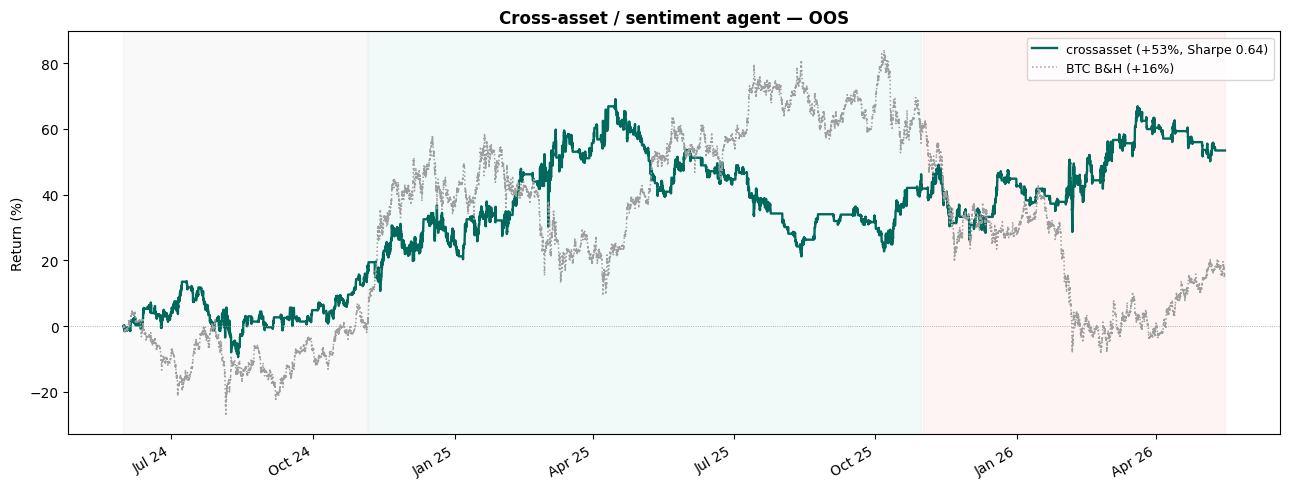

In [5]:
import matplotlib.pyplot as plt, matplotlib.dates as mdates
oos = (df.index >= OOS_START) & (df.index <= OOS_END); sub = df[oos]
p = out["_probs"][oos].values
eq, pos, _ = bracket_run(p, sub["close"].values, sub["high"].values, sub["low"].values,
                         sub["atr_14_pct"].values, with_fees=True, **out["best_params"])
bh = (sub["close"].values / sub["close"].values[0] - 1) * 100
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(sub.index, (eq - 1) * 100, lw=1.7, color="#00695C",
        label=f"crossasset ({eq[-1]-1:+.0%}, Sharpe {sharpe(eq):.2f})")
ax.plot(sub.index, bh, lw=1.1, ls=":", color="#9E9E9E", label=f"BTC B&H ({bh[-1]:+.0f}%)")
for rg, c in [("chop", "#9E9E9E"), ("bull", "#26A69A"), ("bear", "#EF5350")]:
    s, e = REGIME_DATES[rg]; ax.axvspan(s, min(e, sub.index[-1]), alpha=0.06, color=c)
ax.axhline(0, color="#9E9E9E", lw=0.6, ls=":"); ax.set_ylabel("Return (%)"); ax.legend(fontsize=9)
ax.set_title("Cross-asset / sentiment agent — OOS", fontweight="bold")
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
fig.tight_layout(); plt.show()